Transformación de Datos
Crea nuevas columnas: Basándonos en los datos existentes, crea nuevas columnas que sean útiles para el análisis. Por ejemplo, calcula el ingreso total por venta y normaliza las ventas.
Clasifica los datos: Crea una columna que clasifique las ventas en categorías significativas (e.g., ‘Alta’, ‘Media’, ‘Baja’).
Agrupación y Agregación
Agrupación por múltiples columnas: Realiza agrupaciones por categorías como producto y tienda, producto y mes, etc.
Aplicar funciones de agregación: Utiliza funciones como sum, mean, count, min, max, std, y var para obtener estadísticas descriptivas de cada grupo.
Análisis Personalizado con apply
Función personalizada: Aplica funciones personalizadas para realizar análisis específicos que no se pueden lograr con las funciones de agregación estándar.
Ejemplo de uso avanzado: Calcula la desviación de cada venta respecto a la media de su grupo.
Documentación
Comentarios claros: Documenta claramente cada paso del análisis, explicando qué se hizo y por qué se hizo.
Código legible: Asegúrate de que el código sea legible y esté bien comentado.

In [1]:
import os
import pandas as pd


# Función para cargar los datos del archivo CSV utilizando pandas
def cargar_datos(ruta_archivo):
    # Cargar los datos del archivo CSV utilizando pandas
    datos = pd.read_csv(ruta_archivo)
    return datos

if __name__ == "__main__":
    # Ruta del archivo CSV
    ruta_archivo = '../retail_sales_dataset.csv'
    
    # Verificar si el archivo existe antes de intentar cargarlo
    if os.path.exists(ruta_archivo):
        # Cargar los datos
        df = cargar_datos(ruta_archivo)
        print(df.head())  # Mostrar las primeras filas del DataFrame
    else:
        print(f"El archivo {"../retail_sales_dataset.csv"} no existe.")



   Transaction ID        Date Customer ID  Gender  Age Product Category  \
0               1  2023-11-24     CUST001    Male   34           Beauty   
1               2  2023-02-27     CUST002  Female   26         Clothing   
2               3  2023-01-13     CUST003    Male   50      Electronics   
3               4  2023-05-21     CUST004    Male   37         Clothing   
4               5  2023-05-06     CUST005    Male   30           Beauty   

   Quantity  Price per Unit  Total Amount  
0         3              50           150  
1         2             500          1000  
2         1              30            30  
3         1             500           500  
4         2              50           100  


In [2]:

df['Date'] = pd.to_datetime(df['Date'])
df.info()
df.isnull().sum()
df.describe()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 70.4+ KB


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [3]:
# Calcular el 'Cost per Unit' restando un 15% del 'Price per Unit'
df['Cost per Unit'] = df['Price per Unit'] * (1 - 0.15)
df.drop('Average Price per Unit', axis=1, inplace=True, errors='ignore')

#Ordenando las columnas
nuevo_orden = ['Transaction ID',"Date",'Customer ID',"Gender", "Age", "Product Category", "Quantity", "Cost per Unit", 'Price per Unit', 'Total Amount']
df = df.reindex(columns=nuevo_orden)

#Creando una nueva columna para el analisis. (profit margin)
df['profit margin'] =df['Price per Unit'] - df["Cost per Unit"]


# Normalizar la columna 'Ventas'
max_value = df['Total Amount'].max()
min_value = df['Total Amount'].min()
df['Total Amount_normalizado'] = df['Total Amount'].apply(lambda x: (x - min_value) / (max_value - min_value))
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Cost per Unit,Price per Unit,Total Amount,profit margin,Total Amount_normalizado
0,1,2023-11-24,CUST001,Male,34,Beauty,3,42.5,50,150,7.5,0.063291
1,2,2023-02-27,CUST002,Female,26,Clothing,2,425.0,500,1000,75.0,0.493671
2,3,2023-01-13,CUST003,Male,50,Electronics,1,25.5,30,30,4.5,0.002532
3,4,2023-05-21,CUST004,Male,37,Clothing,1,425.0,500,500,75.0,0.240506
4,5,2023-05-06,CUST005,Male,30,Beauty,2,42.5,50,100,7.5,0.037975


In [4]:
#Restablecemos el índice para asegurar de que Product Category esté solo como columna y no como índice.
df = df.reset_index(drop=True)

#Clasificación de ventas en categorías significativas (Alta, Media, Baja)

# Definir las categorías según el 'Total Amount'
def clasificar_ventas(total_amount):
    if total_amount >= 500:
        return 'Alta'
    elif total_amount >= 100:
        return 'Media'
    else:
        return 'Baja'

# Crear la nueva columna 'Sales Category' basada en la clasificación
df['Sales Category'] = df['Total Amount'].apply(clasificar_ventas)


# Agrupar los datos por 'Product Category' y 'Gender', y aplicar funciones de agregación
grouped = df.groupby(['Product Category', 'Gender'], as_index=False).agg({
    'Total Amount': ['sum', 'mean', 'count', 'min', 'max', 'std', 'var'],
    'Quantity': ['sum', 'mean']
})

# DataFrame agrupado 'Product Category' y 'Gender'
print("Datos agrupados por 'Product Category' y 'Gender':")
print(grouped)

#Análisis personalizado con apply (Calculando la desviación de cada venta respecto a la media de su grupo)

# Definir una función que calcule la desviación respecto a la media de su grupo
def desviacion_venta(row, mean_by_category):
    categoria = row['Product Category']
    mean_value = mean_by_category[categoria]
    return row['Total Amount'] - mean_value

# Calcular la media por 'Product Category'
mean_by_category = df.groupby('Product Category')['Total Amount'].mean()

# Aplicar la función personalizada al DataFrame
df['Desviación de la media'] = df.apply(lambda row: desviacion_venta(row, mean_by_category), axis=1)

# DataFrame final con la nueva columna 'Desviación de la media'
print("\nDataFrame final con la clasificación de ventas y la desviación de la media:")
print(df)

Datos agrupados por 'Product Category' y 'Gender':
  Product Category  Gender Total Amount                              \
                                    sum        mean count min   max   
0           Beauty  Female        74830  450.783133   166  25  2000   
1           Beauty    Male        68685  487.127660   141  25  2000   
2         Clothing  Female        81275  467.097701   174  25  2000   
3         Clothing    Male        74305  419.802260   177  25  2000   
4      Electronics  Female        76735  451.382353   170  25  2000   
5      Electronics    Male        80170  466.104651   172  25  2000   

                             Quantity            
          std            var      sum      mean  
0  538.735040  290235.443593      418  2.518072  
1  592.899725  351530.083587      353  2.503546  
2  577.016491  332948.030862      441  2.534483  
3  524.116237  274697.829995      453  2.559322  
4  548.644646  301010.947616      439  2.582353  
5  587.129702  344721.287230  

In [5]:
"""import os
import pandas as pd

# Función para cargar los datos del archivo CSV utilizando pandas
def cargar_datos(ruta_archivo):
    # Cargar los datos del archivo CSV utilizando pandas
    datos = pd.read_csv(ruta_archivo)
    return datos

if __name__ == "__main__":
    # Ruta del archivo CSV
    ruta_archivo = '../retail_sales_dataset.csv'"""


# Identificar columnas de tipo 'object'
cols_object = df.select_dtypes(include='object').columns

# Convertir a 'category' y estandarizar en minúsculas
for col in cols_object:
    df[col] = df[col].str.lower().astype('category')

#Convertir la columna date
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

#Datos de tipo float con solamente dos decimales
pd.options.display.float_format = '{:.2f}'.format

# Verificar los cambios
print("Verificando los cambios de los tipos de datos:")
print(df.info())
print("Verificando la correccion en la inconsistencia de los valores:")
print(df.head())
print("Verificando la totalidad de los valores nulos:")
df.isnull().sum()

Verificando los cambios de los tipos de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Transaction ID            1000 non-null   int64         
 1   Date                      1000 non-null   datetime64[ns]
 2   Customer ID               1000 non-null   category      
 3   Gender                    1000 non-null   category      
 4   Age                       1000 non-null   int64         
 5   Product Category          1000 non-null   category      
 6   Quantity                  1000 non-null   int64         
 7   Cost per Unit             1000 non-null   float64       
 8   Price per Unit            1000 non-null   int64         
 9   Total Amount              1000 non-null   int64         
 10  profit margin             1000 non-null   float64       
 11  Total Amount_normalizado  1000 non-n

Transaction ID              0
Date                        0
Customer ID                 0
Gender                      0
Age                         0
Product Category            0
Quantity                    0
Cost per Unit               0
Price per Unit              0
Total Amount                0
profit margin               0
Total Amount_normalizado    0
Sales Category              0
Desviación de la media      0
dtype: int64

In [6]:
#Calcula estadísticas descriptivas básicas para comprender mejor las características de los datos.
print("Verificando la totalidad de los valores nulos:")
df.describe()

Verificando la totalidad de los valores nulos:


,Transaction ID,Date,Age,Quantity,Cost per Unit,Price per Unit,Total Amount,profit margin,Total Amount_normalizado,Desviación de la media
count,1000.00,1000,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,500.50,2023-07-03 00:25:55.200000256,41.39,2.51,152.91,179.89,456.00,26.98,0.22,0.00
min,1.00,2023-01-01 00:00:00,18.00,1.00,21.25,25.00,25.00,3.75,0.00,-442.48
25%,250.75,2023-04-08 00:00:00,29.00,1.00,25.50,30.00,60.00,4.50,0.02,-392.48
50%,500.50,2023-06-29 12:00:00,42.00,3.00,42.50,50.00,135.00,7.50,0.06,-320.36
75%,750.25,2023-10-04 00:00:00,53.00,4.00,255.00,300.00,900.00,45.00,0.44,432.52
max,1000.00,2024-01-01 00:00:00,64.00,4.00,425.00,500.00,2000.00,75.00,1.00,1556.75
std,288.82,NaN,13.68,1.13,161.23,189.68,560.00,28.45,0.28,559.91


In [ ]:
%pip install matplotlib seaborn



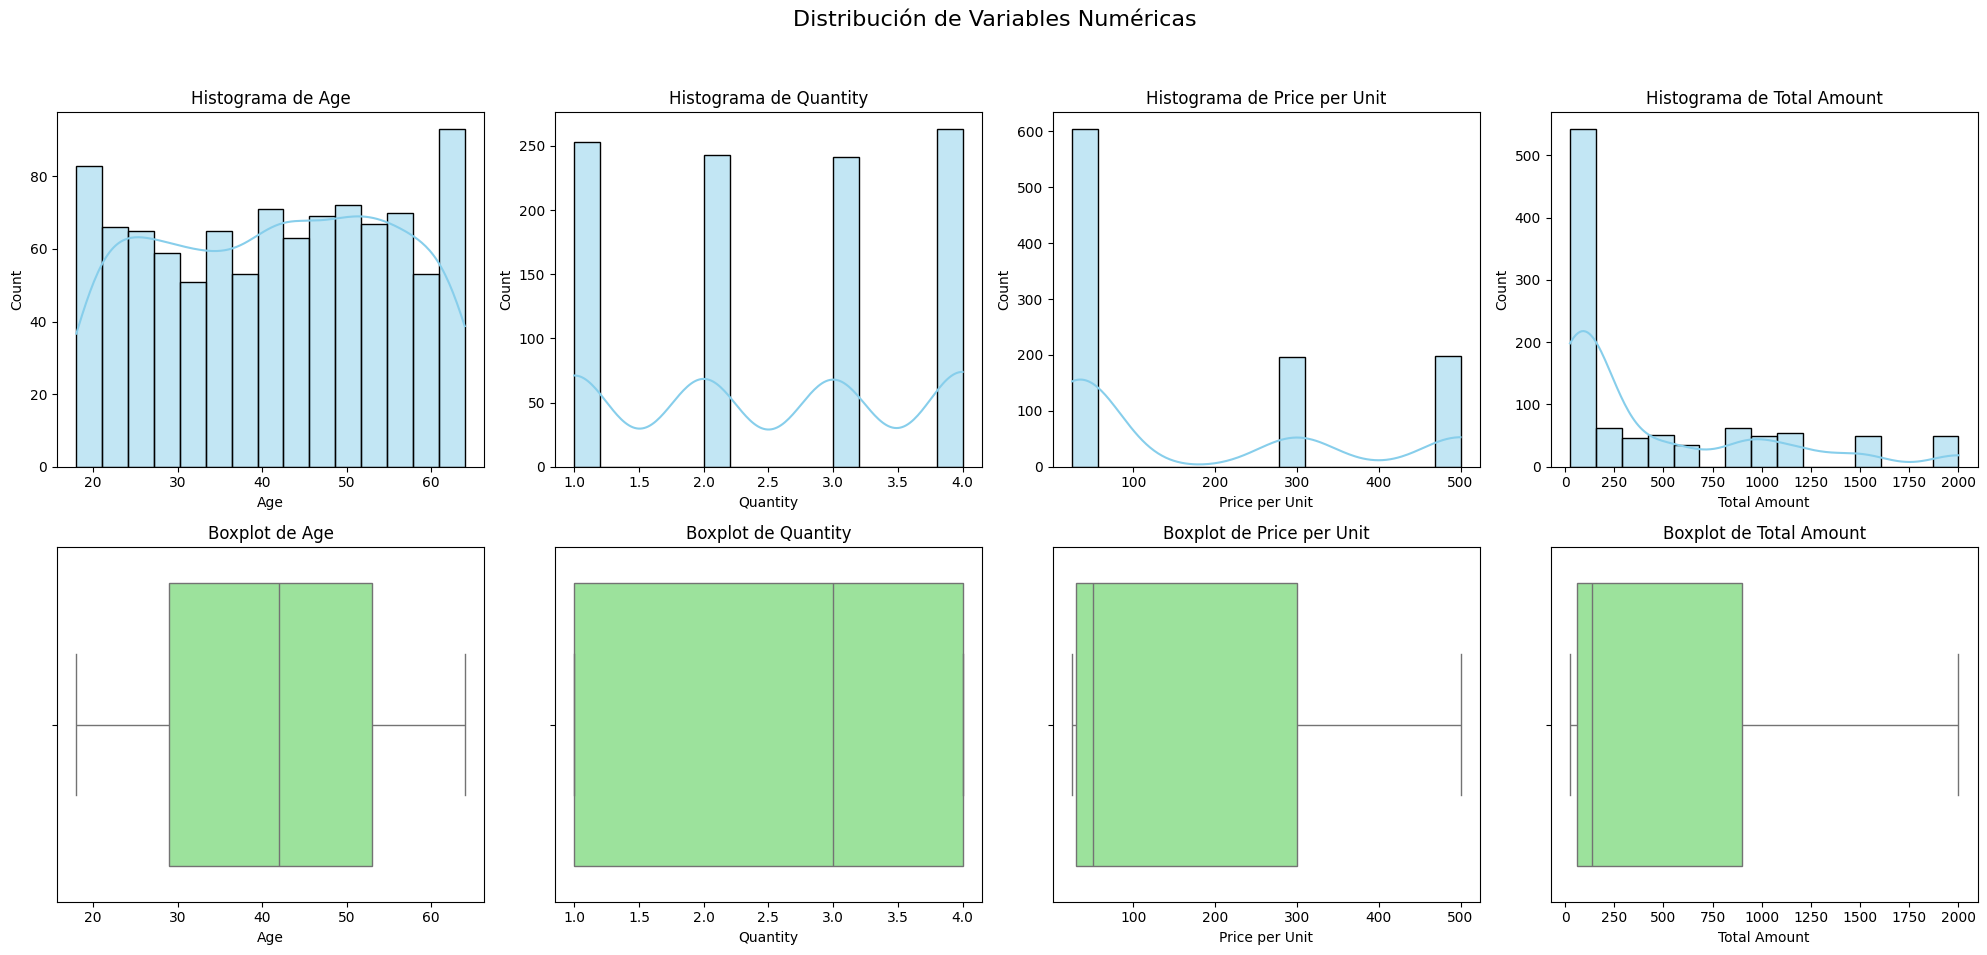

In [7]:
#Utiliza histogramas y boxplots para visualizar la distribución de las variables numéricas clave.
import matplotlib.pyplot as plt
import seaborn as sns

# Lista de las columnas numéricas a visualizar
variables = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']

# Configuración general de la figura
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
fig.suptitle('Distribución de Variables Numéricas', fontsize=16)

# Crear histogramas y boxplots
for i, variable in enumerate(variables):
    # Histograma
    sns.histplot(df[variable], bins=15, kde=True, ax=axes[0, i], color='skyblue')
    axes[0, i].set_title(f'Histograma de {variable}')
    
    # Boxplot
    sns.boxplot(x=df[variable], ax=axes[1, i], color='lightgreen')
    axes[1, i].set_title(f'Boxplot de {variable}')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Ajustar el layout para el título
plt.show()

In [ ]:
"""Conclusiones de los graficos:
-Edad (Age)
Histograma: La distribución de la edad parece ser uniforme, con una distribución bastante pareja entre los diferentes grupos de edad, sin un pico evidente en una edad específica.
Boxplot: La distribución de edad no tiene valores atípicos visibles, y la mediana parece estar alrededor de los 40 años. Esto indica que la edad de los clientes está bien distribuida dentro de un rango estándar.
-Cantidad (Quantity)
Histograma: La cantidad parece estar agrupada en valores específicos (posiblemente 1, 2, 3 y 4), lo que indica que la variable Quantity es discreta. Esto sugiere que los clientes tienden a comprar un número limitado de unidades por transacción.
Boxplot: Los valores son consistentes y no hay valores atípicos, lo que reafirma la distribución en números específicos.
-Precio por unidad (Price per Unit)
Histograma: Se registra un pico más alto en los precios unitarios menores a 100 y una distribución de precios alrededor de los 50, 300 y 500.-
Boxplot: La mediana de los precios por unidad es 50.-
-Monto total (Total Amount)
Histograma: La mayoría de las transacciones tienen montos totales bajos, con una concentración alrededor de los 135. Conforme el monto aumenta, la frecuencia disminuye, lo que indica que las compras grandes son menos comunes.
Boxplot: La mayoría del total de los productos vendidos, se encuentran entre los valores (60 y 900).
Conclusión General
La mayoría de las variables numéricas están bien distribuidas.-
La cantidad de unidades compradas sugiere que los clientes tienden a comprar en pequeños lotes, mientras que el rango de edad amplio indica que la tienda tiene un público diverso."""

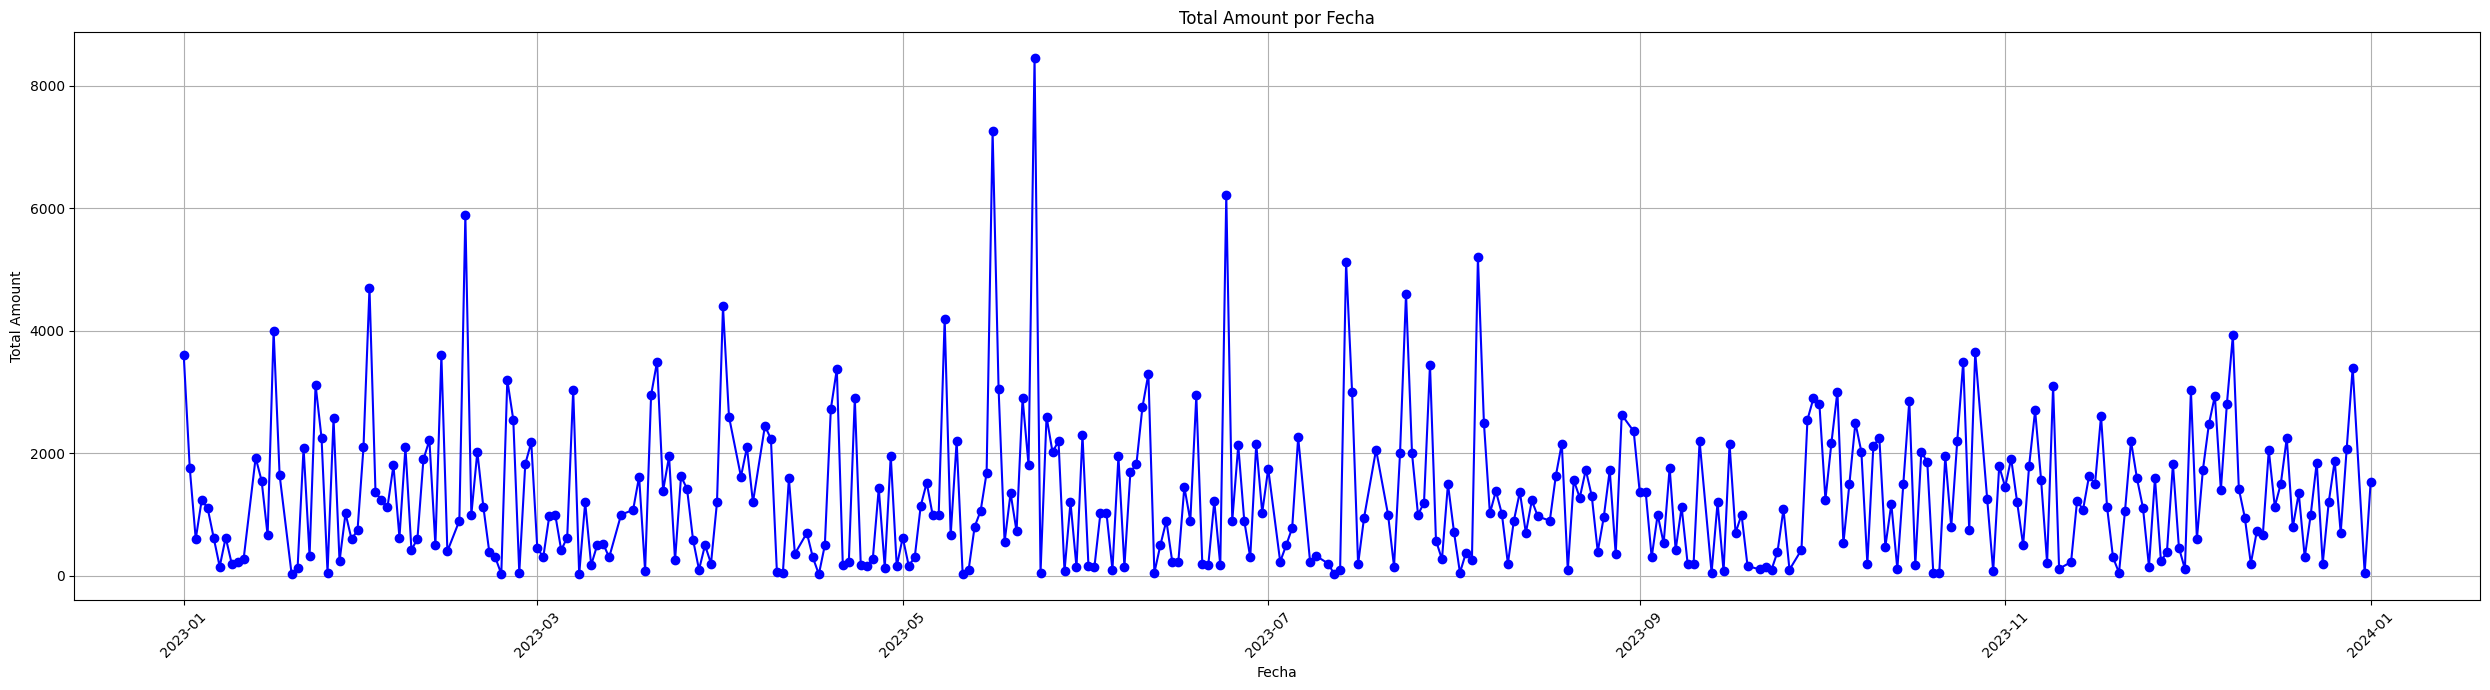

In [10]:
#Crea gráficos de líneas para mostrar las tendencias de ventas a lo largo del tiempo.
# Agrupar por fecha y sumar el Total Amount
total_enTiempo = df.groupby('Date')['Total Amount'].sum()

# Crear un gráfico de líneas
plt.figure(figsize=(25, 7))
plt.plot(total_enTiempo.index, total_enTiempo.values, marker='o', linestyle='-', color='b')
plt.title('Total Amount por Fecha')
plt.xlabel('Fecha')
plt.ylabel('Total Amount')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

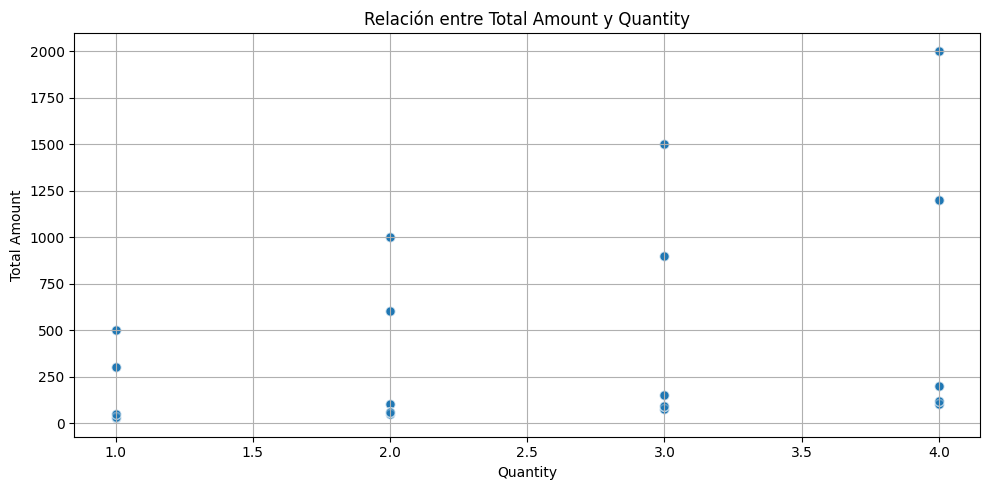

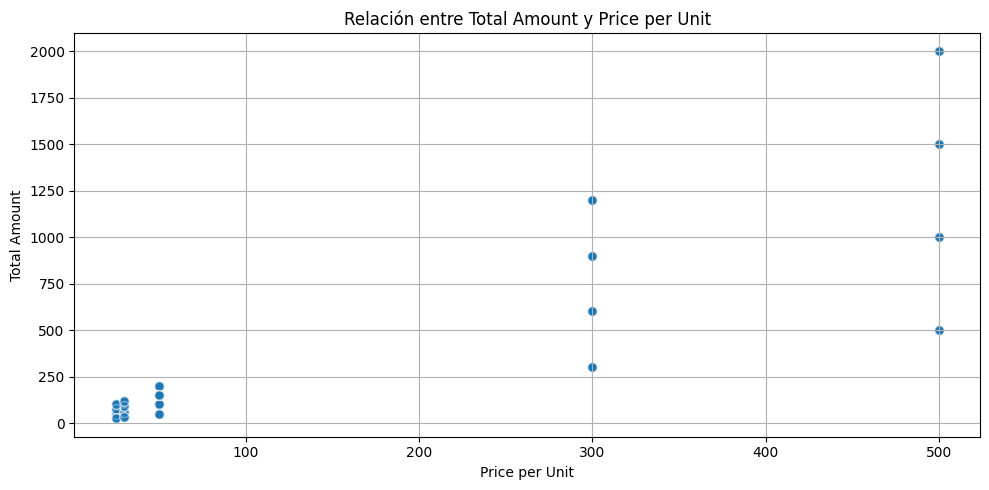

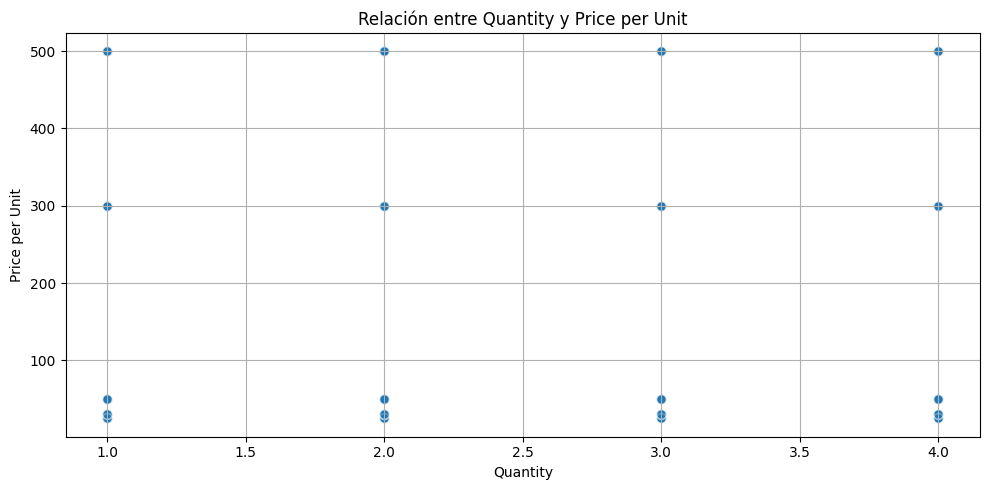

In [11]:
#Utiliza gráficos de dispersión para analizar la relación entre diferentes variables.
#Relación entre "Total Amount" y "Quantity"
plt.figure(figsize=(10, 5))
plt.scatter(df['Quantity'], df['Total Amount'], alpha=0.6, edgecolors='w', s=50)
plt.title('Relación entre Total Amount y Quantity')
plt.xlabel('Quantity')
plt.ylabel('Total Amount')
plt.grid()
plt.tight_layout()
plt.show()

#Relación entre "Total Amount" y "Price per Unit"
plt.figure(figsize=(10, 5))
plt.scatter(df['Price per Unit'], df['Total Amount'], alpha=0.6, edgecolors='w', s=50)
plt.title('Relación entre Total Amount y Price per Unit')
plt.xlabel('Price per Unit')
plt.ylabel('Total Amount')
plt.grid()
plt.tight_layout()
plt.show()

#Relación entre "Quantity" y "Price per Unit"
plt.figure(figsize=(10, 5))
plt.scatter(df['Quantity'], df['Price per Unit'], alpha=0.6, edgecolors='w', s=50)
plt.title('Relación entre Quantity y Price per Unit')
plt.xlabel('Quantity')
plt.ylabel('Price per Unit')
plt.grid()
plt.tight_layout()
plt.show()


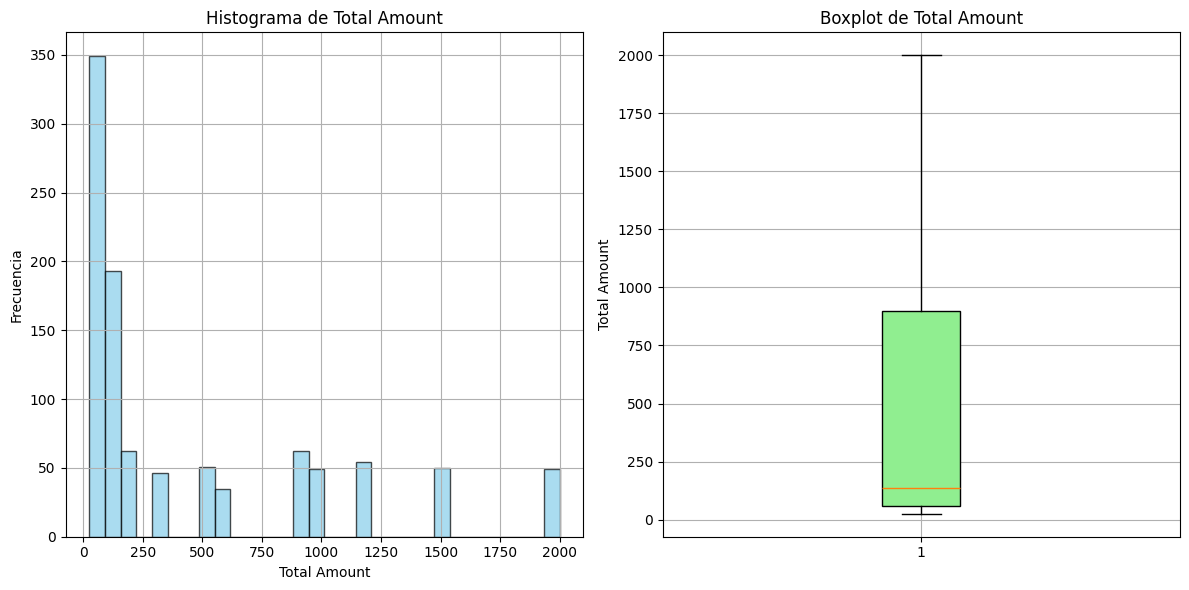

In [12]:
#Combina histogramas y boxplots para visualizar la distribución de las ventas y detectar valores atípicos.
plt.figure(figsize=(12, 6))

# Subgráfico para el histograma
plt.subplot(1, 2, 1)
plt.hist(df['Total Amount'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Histograma de Total Amount')
plt.xlabel('Total Amount')
plt.ylabel('Frecuencia')
plt.grid()

# Subgráfico para el boxplot
plt.subplot(1, 2, 2)
plt.boxplot(df['Total Amount'], vert=True, patch_artist=True, boxprops=dict(facecolor='lightgreen'))
plt.title('Boxplot de Total Amount')
plt.ylabel('Total Amount')
plt.grid()

plt.tight_layout()
plt.show()

In [ ]:
"""Conclusiones:Tanto el histograma como el boxplot indican que podrían existir valores atípicos, principalmente en la parte superior del rango de "Total Amount". La distribución de "Total Amount" parece estar sesgada hacia la derecha, lo que podría influir en los cálculos estadísticos tradicionales."""

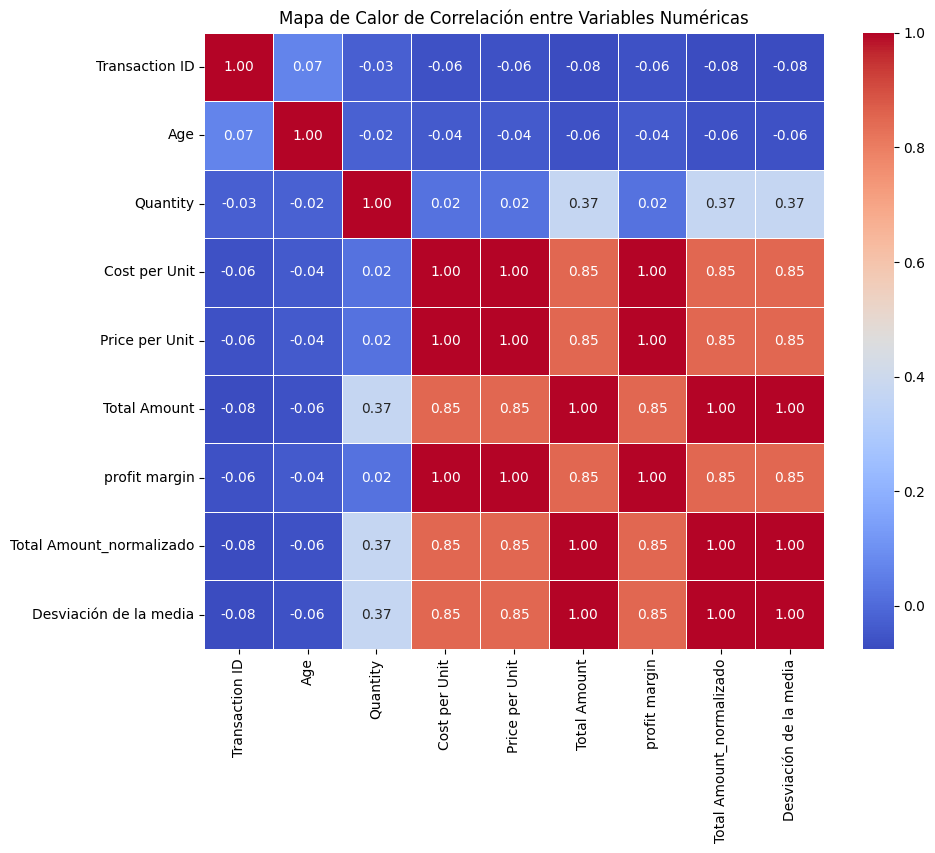

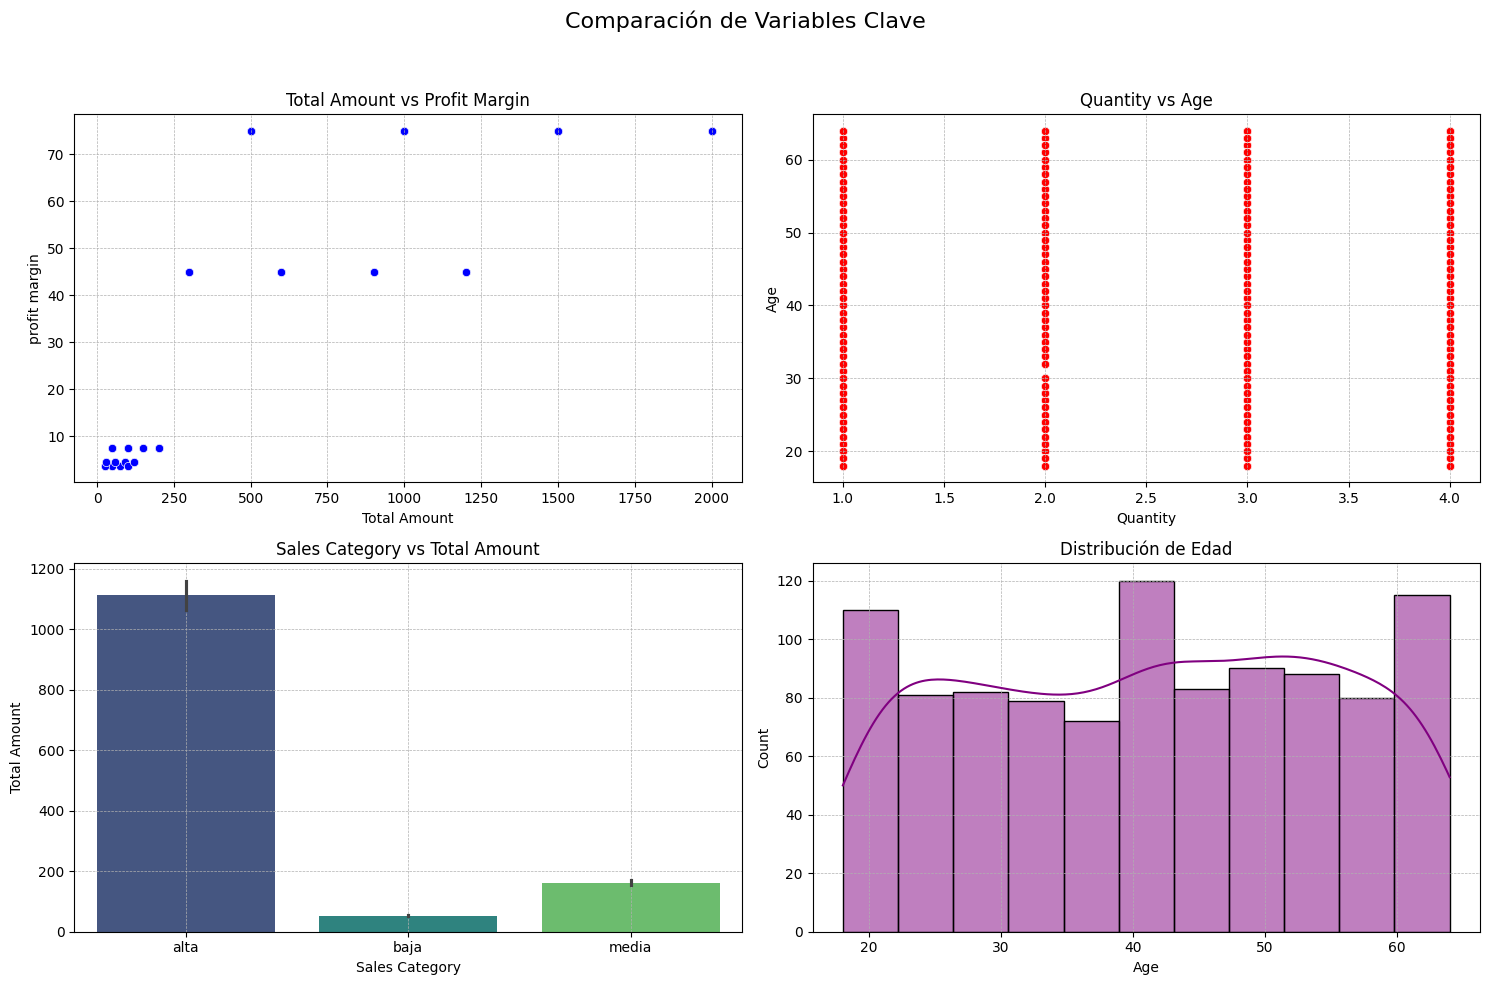

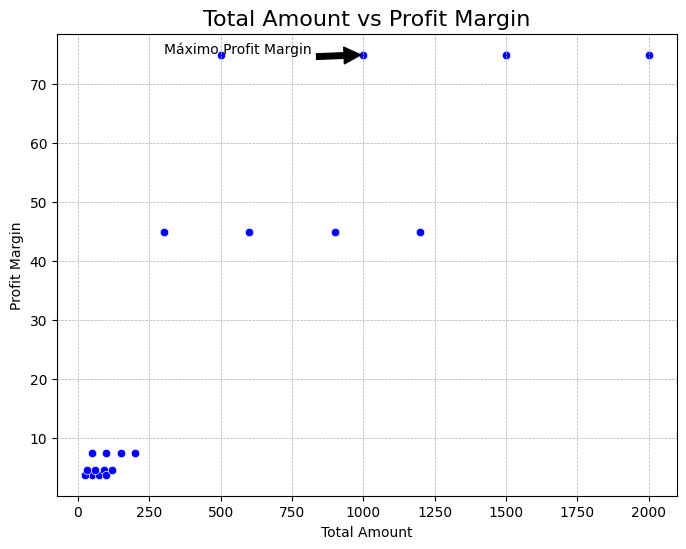

In [32]:
# Exploración de Datos Avanzada
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Asegurarse de filtrar las columnas numéricas y de eliminar cualquier fila con datos faltantes
numeric_df = df.select_dtypes(include=[float, int]).dropna()

# Realizar un análisis de correlación y crear un mapa de calor para visualizar las relaciones entre las variables
if not numeric_df.empty and numeric_df.shape[1] > 1:
    # Calcular la matriz de correlación usando numeric_df en lugar de df
    correlation_matrix = numeric_df.corr()

    # Configurar el tamaño de la figura
    plt.figure(figsize=(10, 8))

    # Crear el mapa de calor con anotaciones
    sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
    plt.title("Mapa de Calor de Correlación entre Variables Numéricas")
    plt.show()
else:
    print("No hay suficientes datos numéricos para calcular la correlación.")

# Crear subplots para comparar diferentes variables clave
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Comparación de Variables Clave", fontsize=16)

# Gráfico de dispersión Total Amount vs Profit Margin
sns.scatterplot(data=df, x="Total Amount", y="profit margin", ax=axes[0, 0], color='b')
axes[0, 0].set_title("Total Amount vs Profit Margin")
axes[0, 0].grid(True, linestyle='--', linewidth=0.5)

# Gráfico de dispersión Quantity vs Age
sns.scatterplot(data=df, x="Quantity", y="Age", ax=axes[0, 1], color='r')
axes[0, 1].set_title("Quantity vs Age")
axes[0, 1].grid(True, linestyle='--', linewidth=0.5)

# Gráfico de barras Sales Category vs Total Amount
sns.barplot(data=df, x="Sales Category", y="Total Amount", hue="Sales Category", ax=axes[1, 0], palette="viridis", dodge=False)
axes[1, 0].set_title("Sales Category vs Total Amount")
axes[1, 0].grid(True, linestyle='--', linewidth=0.5)

# Histograma de Age
sns.histplot(data=df, x="Age", kde=True, color="purple", ax=axes[1, 1])
axes[1, 1].set_title("Distribución de Edad")
axes[1, 1].grid(True, linestyle='--', linewidth=0.5)

# Ajuste del layout
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Añadir cuadrículas, leyendas, anotaciones y flechas a tus gráficos para mejorar la claridad y la información
# Anotaciones en el subplot de Total Amount vs Profit Margin
fig, ax = plt.subplots(figsize=(8, 6))

# Gráfico de dispersión con anotación
sns.scatterplot(data=df, x="Total Amount", y="profit margin", ax=ax, color='b')
ax.set_title("Total Amount vs Profit Margin", fontsize=16)
ax.set_xlabel("Total Amount")
ax.set_ylabel("Profit Margin")

# Añadir anotación y flecha en el punto máximo de Profit Margin
max_profit = df["profit margin"].idxmax()  # Índice del máximo Profit Margin
ax.annotate('Máximo Profit Margin', 
            xy=(df['Total Amount'][max_profit], df['profit margin'][max_profit]), 
            xytext=(df['Total Amount'][max_profit] - 700, df['profit margin'][max_profit] + 0.15),
            arrowprops=dict(facecolor='black', shrink=0.05))


# Añadir cuadrícula
ax.grid(True, linestyle='--', linewidth=0.5)

plt.show()


